# (Short) EDA of the datasets

In [66]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("paper")

langcols = {
    'English': '#0474BA',
    'Greek': '#00A7E1',
    'Spanish': '#FFA630'
}

noise_order = ['randomly_swapped_words', 'consecutively_swapped_words', 'deleted_words', 'removed_sentence', 'inserted_sentence', 'repeated_sentence']

## Merged datasets

In [2]:
df = pd.read_parquet('../results/eda/text_stats.parquet')
reports = df[df['doc_type'] == 'annual_reports']
golds = df[df['doc_type'] == 'gold_summaries']
cands = df[df['doc_type'] == 'candidate_summaries_trunc']
df

,doc_id,dataset,version,noise_variant,doc_type,language,text,spacy_token_count,spacy_sent_count,bert_token_count
0,10063,training,None,None,annual_reports,English,MELROSE PLC ANNUAL REPORT 2006\nMelrose PLC\n...,NaN,NaN,53655.0
1,10068,training,None,None,annual_reports,English,21012-04 Proof 6 26/3/2012 21012-04 Proo...,NaN,NaN,98709.0
2,1007,training,None,None,annual_reports,English,APG01 | AR13 | 28/03/2014 | COVER ART APG01 |...,NaN,NaN,80971.0
3,10073,training,None,None,annual_reports,English,Mentmore plc\nPark House\n14 Pepys Road\nLond...,NaN,NaN,31488.0
4,1008,training,None,None,annual_reports,English,2014 \nAnnual Report & Accounts\nANGLO PACIFI...,NaN,NaN,80542.0
...,...,...,...,...,...,...,...,...,...,...
38686,0178,training,GS1,None,gold_summaries,Spanish,Este año 2016 hemos celebrado un aniversario e...,1412.0,42.0,1808.0
38687,0179,training,GS1,None,gold_summaries,Spanish,El nivel de participación de los extranjeros t...,1043.0,36.0,1307.0
38688,0180,training,GS1,None,gold_summaries,Spanish,Un año más tengo el placer de dirigirme a uste...,594.0,14.0,757.0
38689,0181,training,GS1,None,gold_summaries,Spanish,NH Hotel Group ha dado grandes pasos desde que...,816.0,18.0,1060.0


In [8]:
print('Filtered document counts by language and type:')

pd.crosstab(df['doc_type'], df['language'])

Filtered document counts by language and type:


language,English,Greek,Spanish
doc_type,,,
annual_reports,817,212,182
candidate_summaries_trunc,24480,6330,5460
gold_summaries,816,212,182


## Annual reports

In [25]:
reports['bert_token_count'].describe().round(2)

count      1211.00
mean      72477.88
std       56421.85
min         451.00
25%       37828.50
50%       61077.00
75%       92003.00
max      808708.00
Name: bert_token_count, dtype: float64

Text(0, 0.5, 'Word Tokens')

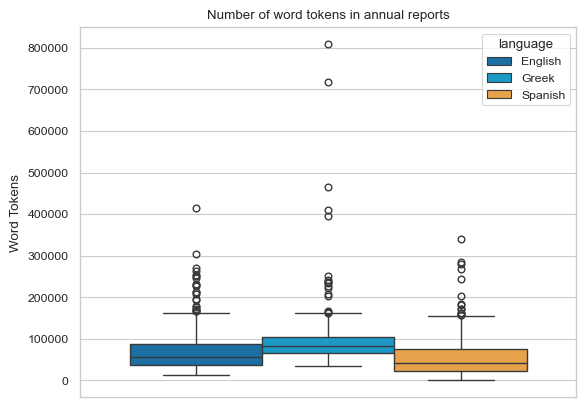

In [ ]:
sns.boxplot(data=reports, y='bert_token_count', hue='language', palette=langcols)
plt.title('Number of word tokens in annual reports')
plt.ylabel('Word Tokens')

## Gold summaries

In [68]:
print('Gold summary word counts by language:')

golds.groupby(['language'])['spacy_token_count'].describe().round(2).iloc[:, 1:]

Gold summary word counts by language:


,mean,std,min,25%,50%,75%,max
language,,,,,,,
English,2732.62,2097.88,51.0,1488.75,2273.0,3421.25,25459.0
Greek,19093.30,12525.74,0.0,11035.50,16006.5,22045.00,84078.0
Spanish,920.57,245.16,249.0,722.50,994.0,1089.50,1711.0


(0.0, 22045.0)

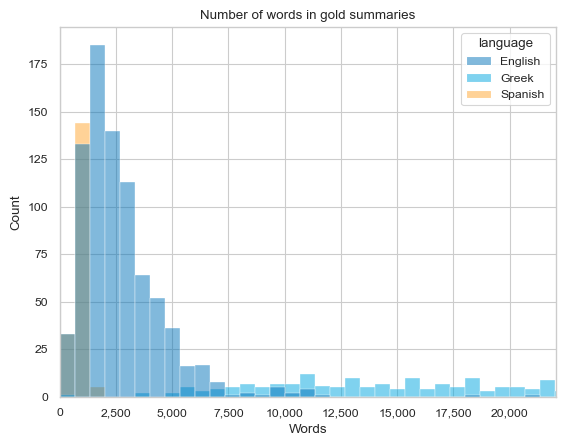

In [67]:
ax = sns.histplot(data=golds, x='spacy_token_count', hue='language', palette=langcols)
plt.title('Number of words in gold summaries')
plt.xlabel('Words')
ax.get_xaxis().set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
plt.xlim(0, golds[golds['language'] == 'Greek']['spacy_token_count'].quantile(0.75))

Text(40.6211283854167, 0.5, 'Words')

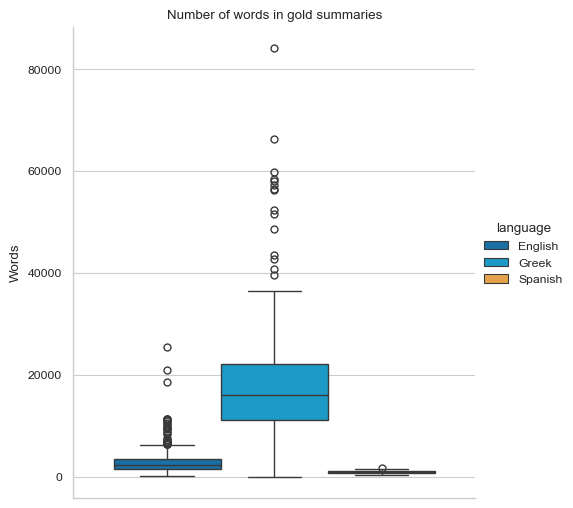

In [ ]:
sns.catplot(data=golds, y='spacy_token_count', hue='language', palette=langcols, kind='box')
plt.title('Number of words in gold summaries')
plt.ylabel('Words')

(0.0, 632.5)

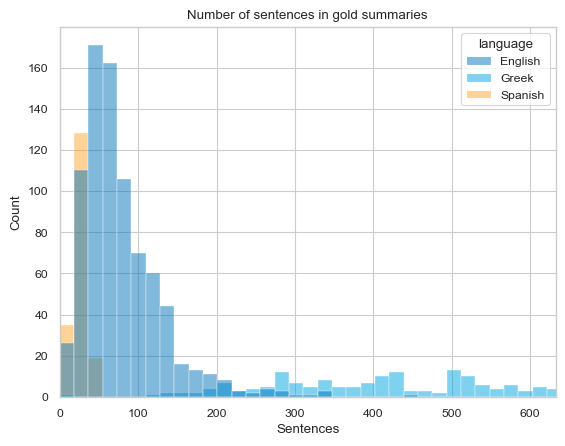

In [69]:
sns.histplot(data=golds, x='spacy_sent_count', hue='language', palette=langcols)
plt.title('Number of sentences in gold summaries')
plt.xlabel('Sentences')
plt.xlim(0, golds[golds['language'] == 'Greek']['spacy_sent_count'].quantile(0.75))

Text(39.40597213541669, 0.5, 'Sentences')

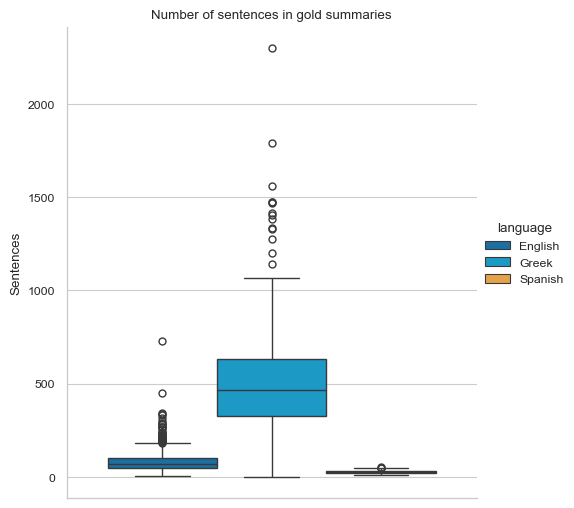

In [16]:
sns.catplot(data=golds, y='spacy_sent_count', hue='language', palette=langcols, kind='box')
plt.title('Number of sentences in gold summaries')
plt.ylabel('Sentences')

In [79]:
print('Gold summary word token counts by language:')

golds.groupby(['language'])['bert_token_count'].describe().round(2).iloc[:, 1:]

Gold summary word token counts by language:


,mean,std,min,25%,50%,75%,max
language,,,,,,,
English,2823.66,2182.72,55.0,1532.75,2288.5,3549.25,28756.0
Greek,45589.28,29874.30,0.0,26576.50,38405.5,52616.00,206134.0
Spanish,1167.34,309.59,311.0,934.50,1254.0,1379.50,2171.0


In [80]:
print('Gold summary word counts:')

golds.bert_token_count.describe().round(2)

Gold summary word counts:


count      1210.00
mean      10067.34
std       20678.08
min           0.00
25%        1380.25
50%        2383.00
75%        4847.50
max      206134.00
Name: bert_token_count, dtype: float64

## Generated summaries

In [82]:
print('Candidate summary word token counts by language:')

cands.groupby(['language'])['bert_token_count'].describe().round(2).iloc[:, 1:]

Candidate summary word token counts by language:


,mean,std,min,25%,50%,75%,max
language,,,,,,,
English,518.56,286.71,0.0,355.0,505.0,618.00,3069.0
Greek,521.91,299.10,0.0,359.0,509.0,636.00,3095.0
Spanish,517.94,273.50,0.0,359.0,510.0,626.25,1730.0


In [83]:
print('Candidate summary word token counts by language (excluding noise variants that extend the text length):')

cands[~cands['noise_variant'].isin(['inserted_sentence', 'repeated_sentence'])].groupby(['language'])['bert_token_count'].describe().round(2).iloc[:, 1:]

Candidate summary word token counts by language (excluding noise variants that extend the text length):


,mean,std,min,25%,50%,75%,max
language,,,,,,,
English,372.44,165.45,0.0,249.0,464.0,505.0,512.0
Greek,370.71,175.19,0.0,244.0,494.0,509.0,510.0
Spanish,375.77,167.37,0.0,253.0,467.0,510.0,510.0


Text(0, 0.5, 'Word tokens')

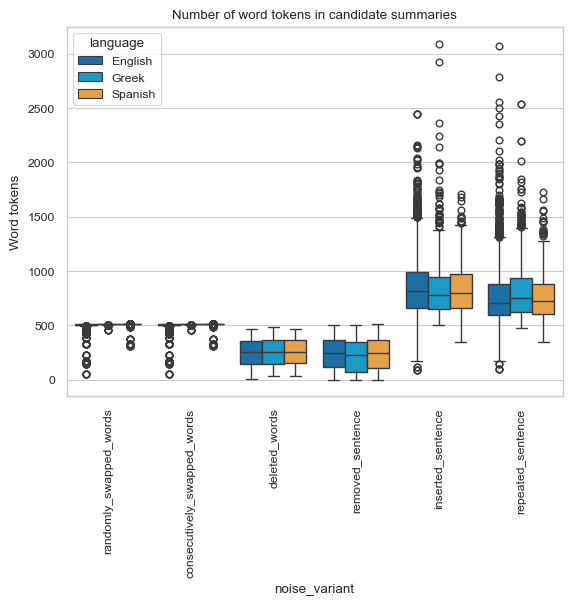

In [35]:
sns.boxplot(data=cands, y='bert_token_count', x='noise_variant', hue='language', palette=langcols, order=noise_order)
plt.title('Number of word tokens in candidate summaries')
plt.xticks(rotation=90)
plt.ylabel('Word tokens')